# Comparison: Monte Carlo Methods vs Theoretical Airy Pattern

This notebook compares Monte Carlo approaches for simulating photon propagation:
1. **Aperture Sampling vs Theoretical Airy**: Validate aperture sampling method
2. **Aperture Sampling vs Angular Spectrum**: Compare two MC approaches

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1

# Import and reload modules to pick up changes
from monte_carlo.core import ApertureSimulator
from monte_carlo.angular_spectrum import AngularSpectrumSimulator
from monte_carlo import metrics
import importlib
import monte_carlo.core
import monte_carlo.angular_spectrum
import monte_carlo.metrics
importlib.reload(monte_carlo.core)
importlib.reload(monte_carlo.angular_spectrum)
importlib.reload(monte_carlo.metrics)
from monte_carlo.core import ApertureSimulator
from monte_carlo.angular_spectrum import AngularSpectrumSimulator
from monte_carlo import metrics

# Set seaborn style
sns.set_theme(style="whitegrid", font_scale=2.0)

# Create output directory
import os
output_dir = '../data/compare_methods'
os.makedirs(output_dir, exist_ok=True)

## Setup Parameters

In [ ]:
# Simulation parameters
n_photons = 500000  # Increased for better statistics
wavelength = 0.532  # microns
focal_length = 10.0  # mm
numerical_aperture = 0.1
n_medium = 1.0
random_seed = 42

# Create simulators
aperture_sim = ApertureSimulator(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    n_medium=n_medium,
    random_seed=random_seed
)

angular_sim = AngularSpectrumSimulator(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    n_medium=n_medium,
    random_seed=random_seed + 1  # Different seed for independence
)

airy_radius = 1.22 * wavelength / numerical_aperture

print(f"Running simulations with {n_photons} photons...")
print(f"Wavelength: {wavelength} μm")
print(f"NA: {numerical_aperture}")
print(f"Focal length: {focal_length} mm")
print(f"First Airy zero: {airy_radius:.4f} μm")

Running simulations with 1000000 photons...
Wavelength: 0.532 μm
NA: 0.1
Focal length: 10.0 mm
First Airy zero: 6.4904 μm


## Run Simulations

In [180]:
# Run both simulations
print("Running aperture sampling...")
aperture_results = aperture_sim.propagate()

print("Running angular spectrum...")
angular_results = angular_sim.propagate()

# Extract focal plane positions
x_ap, y_ap, z_ap = aperture_results['focal_positions']
x_ang, y_ang, z_ang = angular_results['focal_positions']

# Extract k-vectors for angular spectrum method
kx, ky, kz = angular_results['k_vectors']
k = 2 * np.pi * n_medium / wavelength

print("\nSimulations complete!")
print(f"\nVerifying k-vector physics (Angular Spectrum):")
print(f"  k = 2πn/λ = {k:.4f}")
print(f"  k_max (from NA) = {angular_sim.k_max:.4f}")
print(f"  max(√(kx²+ky²)) = {np.sqrt(kx**2 + ky**2).max():.4f}")
print(f"  Checking k² = kx² + ky² + kz²:")
k_magnitude = np.sqrt(kx**2 + ky**2 + kz**2)
print(f"    Expected: {k:.6f}")
print(f"    Got (mean): {k_magnitude.mean():.6f}")
print(f"    Relative error: {np.abs(k_magnitude - k).max() / k * 100:.6f}%")

Running aperture sampling...
Running angular spectrum...

Simulations complete!

Verifying k-vector physics (Angular Spectrum):
  k = 2πn/λ = 11.8105
  k_max (from NA) = 1.1810
  max(√(kx²+ky²)) = 1.1810
  Checking k² = kx² + ky² + kz²:
    Expected: 11.810499
    Got (mean): 11.810499
    Relative error: 0.000000%


## Angular Spectrum Visualization

Visualize the k-space distribution that we're sampling from for the angular spectrum method.

In [ ]:
# Visualize the angular spectrum in k-space
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot 1: 2D Angular Spectrum from FFT
ax = axes[0]
extent = [angular_sim.kx_grid.min(), angular_sim.kx_grid.max(), 
          angular_sim.ky_grid.min(), angular_sim.ky_grid.max()]
im = ax.imshow(angular_sim.angular_spectrum_2d, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='|FFT|²')
ax.set_xlabel('kx (mm⁻¹)')
ax.set_ylabel('ky (mm⁻¹)')
ax.set_title('Angular Spectrum |FFT|²', fontweight='bold')
circle = plt.Circle((0, 0), angular_sim.k_max, fill=False, color='cyan', linewidth=3, label='k_max (NA limit)')
ax.add_patch(circle)
ax.legend()
ax.set_xlim(-2*angular_sim.k_max, 2*angular_sim.k_max)
ax.set_ylim(-2*angular_sim.k_max, 2*angular_sim.k_max)

# Plot 2: 2D histogram of sampled (kx, ky)
ax = axes[1]
h = ax.hist2d(kx, ky, bins=100, cmap='hot')
plt.colorbar(h[3], ax=ax, label='Count')
ax.set_xlabel('kx (mm⁻¹)')
ax.set_ylabel('ky (mm⁻¹)')
ax.set_title('Sampled k-vectors (MC)', fontweight='bold')
circle = plt.Circle((0, 0), angular_sim.k_max, fill=False, color='cyan', linewidth=3, label='k_max')
ax.add_patch(circle)
ax.legend()
ax.set_xlim(-1.5*angular_sim.k_max, 1.5*angular_sim.k_max)
ax.set_ylim(-1.5*angular_sim.k_max, 1.5*angular_sim.k_max)

# Plot 3: Radial profile comparison
ax = axes[2]
k_rho_grid = np.sqrt(angular_sim.kx_grid**2 + angular_sim.ky_grid**2)
k_rho_vals = np.linspace(0, angular_sim.k_max, 100)
angular_spectrum_radial = []

for k_r in k_rho_vals:
    mask = (k_rho_grid >= k_r - angular_sim.k_max/50) & (k_rho_grid < k_r + angular_sim.k_max/50)
    if np.any(mask):
        angular_spectrum_radial.append(np.mean(angular_sim.angular_spectrum_2d[mask]))
    else:
        angular_spectrum_radial.append(0)

# Normalize for comparison
angular_spectrum_radial = np.array(angular_spectrum_radial)
angular_spectrum_radial = angular_spectrum_radial / np.max(angular_spectrum_radial)

# Sampled radial distribution
k_rho_sampled = np.sqrt(kx**2 + ky**2)
hist_k, bin_edges = np.histogram(k_rho_sampled, bins=100, range=(0, angular_sim.k_max))
k_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# Normalize by annulus area
bin_areas_k = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)
hist_k_normalized = hist_k / bin_areas_k
hist_k_normalized = hist_k_normalized / np.max(hist_k_normalized)

ax.plot(k_rho_vals, angular_spectrum_radial, linewidth=5, label='Angular Spectrum |FFT|²', color='tab:orange', alpha=0.5)
ax.plot(k_centers, hist_k_normalized, linewidth=5, label='Sampled MC', linestyle='--', color='tab:blue')
ax.set_xlabel('k_ρ (mm⁻¹)')
ax.set_ylabel('Normalized Intensity')
ax.set_title('Radial Profile in k-space', fontweight='bold')
ax.axvline(angular_sim.k_max, color='cyan', linestyle='--', linewidth=2, label='k_max')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, angular_sim.k_max * 1.1])

plt.tight_layout()
plt.savefig(f'{output_dir}/angular_spectrum_kspace.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAngular Spectrum Info:")
print(f"  FFT grid size: {angular_sim.fft_size} x {angular_sim.fft_size}")
print(f"  Valid k-vectors within NA: {len(angular_sim.kx_valid)}")
print(f"  k_max = {angular_sim.k_max:.4f} mm⁻¹")
print(f"  Sampled k_ρ range: [{k_rho_sampled.min():.4f}, {k_rho_sampled.max():.4f}] mm⁻¹")
print(f"  Mean k_ρ: {k_rho_sampled.mean():.4f} mm⁻¹ ({k_rho_sampled.mean()/angular_sim.k_max*100:.1f}% of k_max)")


## Part 1: Aperture Sampling vs Theoretical Airy Pattern

First, validate that the aperture sampling method produces the expected Airy diffraction pattern.

### 2D Pattern Comparison

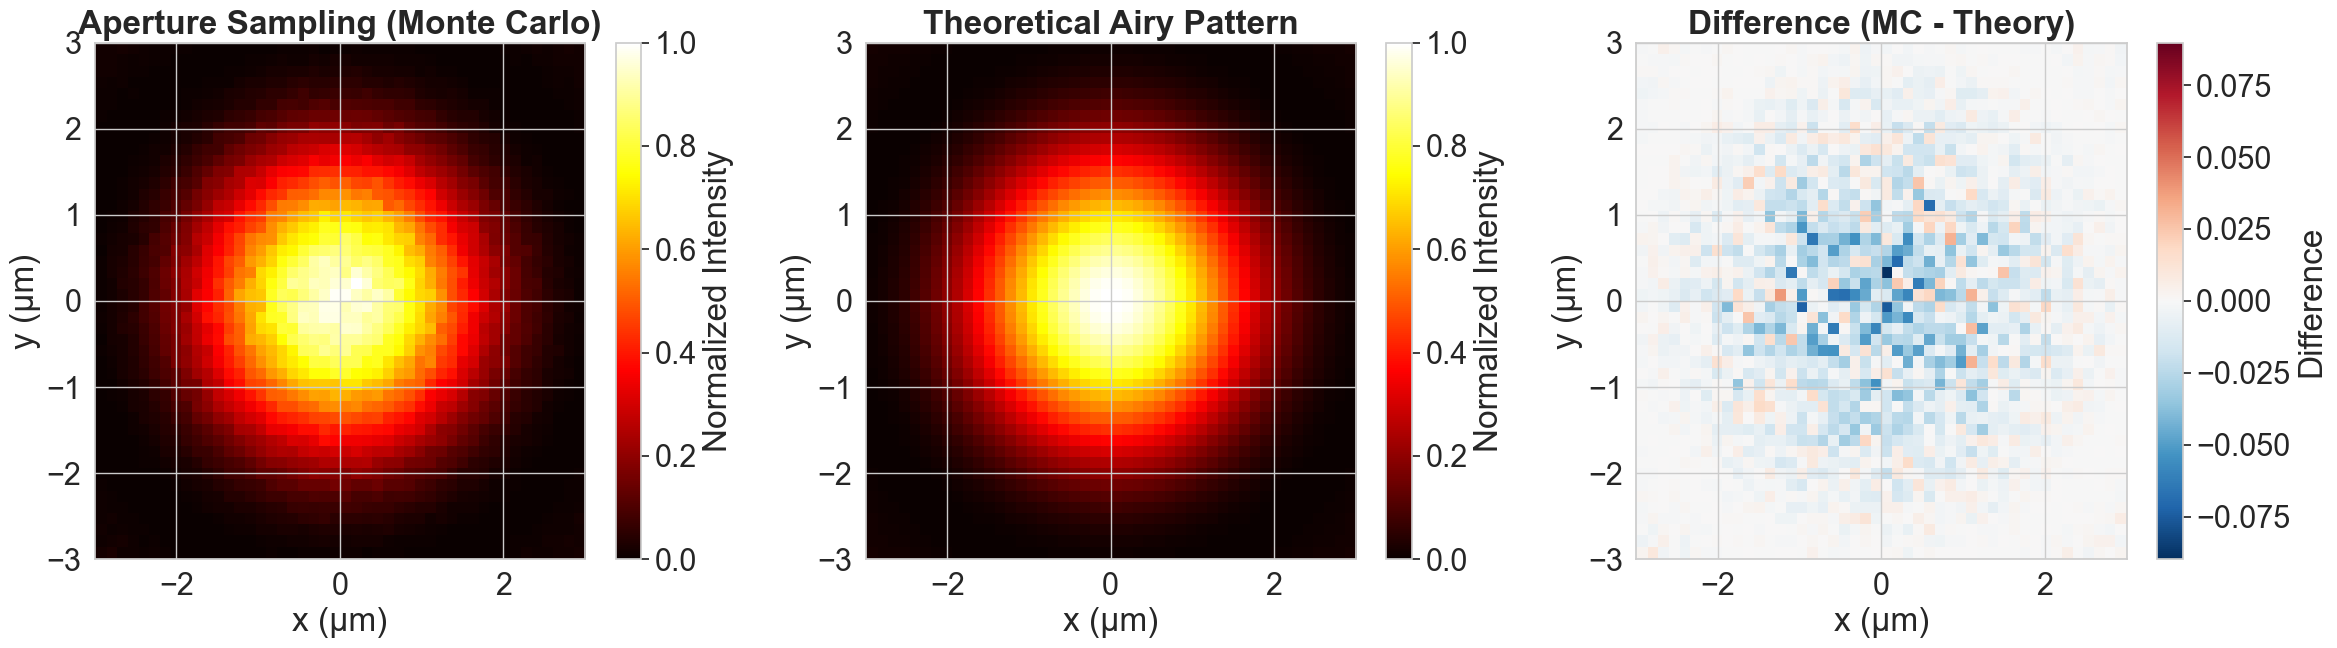

Max absolute difference: 0.089791


In [181]:
# Higher resolution for smoother images
bins_2d = 200
extent_factor = 2
plot_range = extent_factor * airy_radius

# Create 2D histogram for aperture method
hist_ap, xedges, yedges = np.histogram2d(
    x_ap, y_ap, bins=bins_2d, 
    range=[[-plot_range, plot_range], [-plot_range, plot_range]]
)

# Create theoretical Airy pattern on same grid
x_grid = (xedges[:-1] + xedges[1:]) / 2
y_grid = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
R = np.sqrt(X**2 + Y**2)

k_theory = 2 * np.pi * numerical_aperture / wavelength
kr = k_theory * R
airy_2d = np.ones_like(kr)
nonzero = kr != 0
airy_2d[nonzero] = (2 * j1(kr[nonzero]) / kr[nonzero])**2

# Normalize both for comparison
hist_ap_norm = hist_ap / np.max(hist_ap)
airy_2d_norm = airy_2d / np.max(airy_2d)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Aperture sampling
im1 = axes[0].imshow(hist_ap_norm.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='hot', aspect='auto', vmin=0, vmax=1)
axes[0].set_title('Aperture Sampling (Monte Carlo)', fontweight='bold')
axes[0].set_xlabel('x (μm)')
axes[0].set_ylabel('y (μm)')
plt.colorbar(im1, ax=axes[0], label='Normalized Intensity')

# Theoretical Airy
im2 = axes[1].imshow(airy_2d_norm.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='hot', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Theoretical Airy Pattern', fontweight='bold')
axes[1].set_xlabel('x (μm)')
axes[1].set_ylabel('y (μm)')
plt.colorbar(im2, ax=axes[1], label='Normalized Intensity')

# Difference
diff_airy = hist_ap_norm - airy_2d_norm
max_diff = np.abs(diff_airy).max()
im3 = axes[2].imshow(diff_airy.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='RdBu_r', aspect='auto', vmin=-max_diff, vmax=max_diff)
axes[2].set_title('Difference (MC - Theory)', fontweight='bold')
axes[2].set_xlabel('x (μm)')
axes[2].set_ylabel('y (μm)')
plt.colorbar(im3, ax=axes[2], label='Difference')

# Set all xlim and ylim to be -3,3
for ax in axes:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.savefig(f'{output_dir}/part1_2d_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max absolute difference: {max_diff:.6f}")

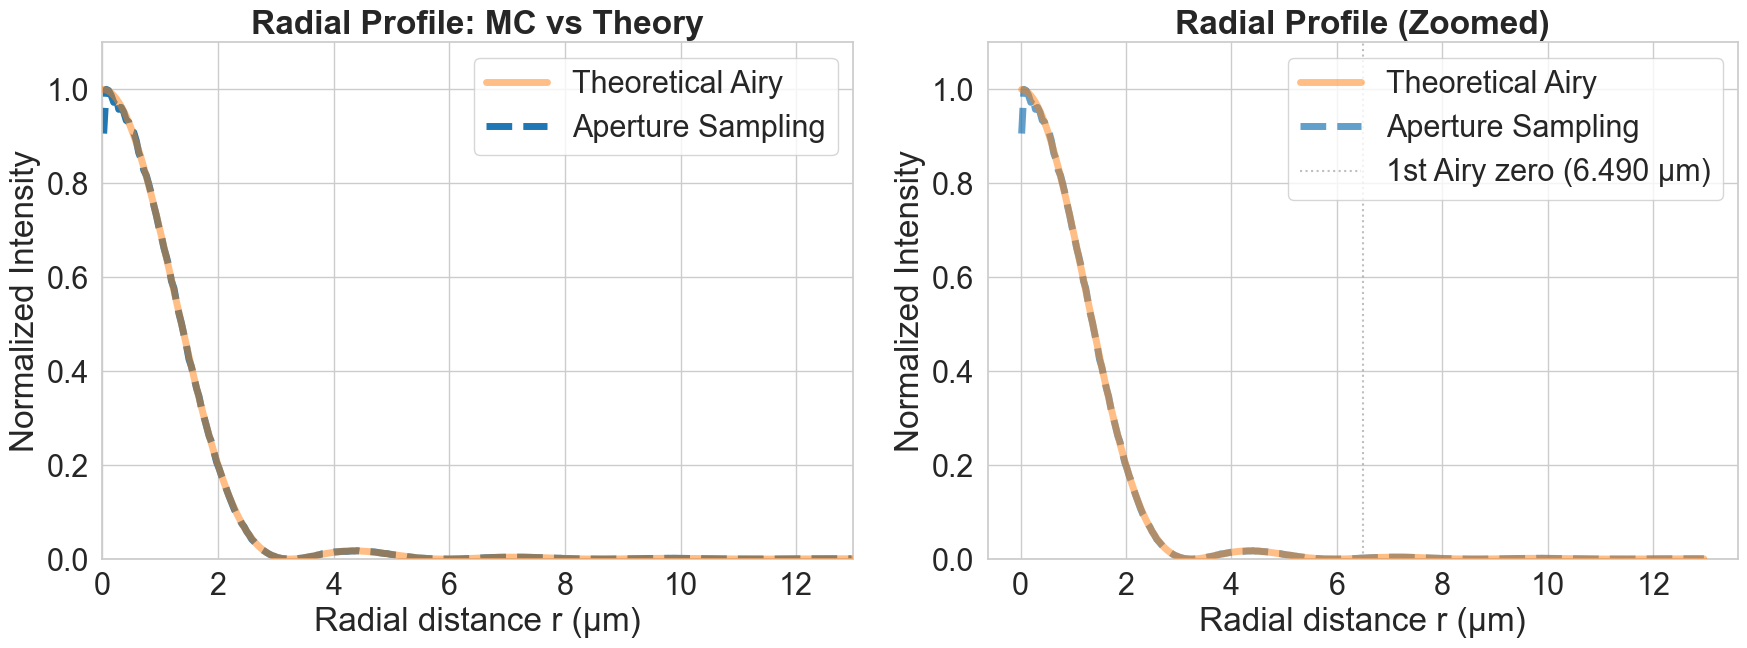


PART 1 METRICS: Aperture Sampling vs Theoretical Airy
RMSE                                     0.005714
NRMSE (normalized)                       0.005714
Fidelity (1.0 = perfect)                 0.999616
Correlation Quality                      0.999808
Relative Structural Content (RST)        0.988884


In [182]:
# Calculate radial distances
r_ap = np.sqrt(x_ap**2 + y_ap**2)

# Create radial histogram with higher resolution
r_bins = np.linspace(0, plot_range, 300)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2

hist_r_ap, _ = np.histogram(r_ap, bins=r_bins)

# Normalize by bin area (annulus area = pi * (r_outer^2 - r_inner^2))
bin_areas = np.pi * (r_bins[1:]**2 - r_bins[:-1]**2)
intensity_r_ap = hist_r_ap / bin_areas

# Normalize to peak
intensity_r_ap = intensity_r_ap / np.max(intensity_r_ap)

# Theoretical Airy pattern
kr_theory = k_theory * r_centers
airy_theory = np.ones_like(kr_theory)
nonzero = kr_theory != 0
airy_theory[nonzero] = (2 * j1(kr_theory[nonzero]) / kr_theory[nonzero])**2

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full radial profile
axes[0].plot(r_centers, airy_theory, color="tab:orange", alpha=0.5, linewidth=5, label='Theoretical Airy', zorder=3)
axes[0].plot(r_centers, intensity_r_ap, color="tab:blue", linewidth=5, label='Aperture Sampling', linestyle="--")
axes[0].set_xlabel('Radial distance r (μm)')
axes[0].set_ylabel('Normalized Intensity')
axes[0].set_title('Radial Profile: MC vs Theory', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].set_xlim([0, plot_range])
axes[0].set_ylim([0, 1.1])

# Zoomed in on first few Airy rings
zoom_range = 3 * airy_radius
zoom_mask = r_centers < zoom_range
axes[1].plot(r_centers[zoom_mask], airy_theory[zoom_mask], color="tab:orange", alpha=0.5, linewidth=5, 
            label='Theoretical Airy', zorder=3)
axes[1].plot(r_centers[zoom_mask], intensity_r_ap[zoom_mask], color="tab:blue", alpha=0.7, linewidth=5, 
            label='Aperture Sampling', linestyle="--")
axes[1].axvline(airy_radius, color='gray', linestyle=':', alpha=0.5, linewidth=1.5,
               label=f'1st Airy zero ({airy_radius:.3f} μm)')
axes[1].set_xlabel('Radial distance r (μm)')
axes[1].set_ylabel('Normalized Intensity')
axes[1].set_title('Radial Profile (Zoomed)', fontweight='bold')
axes[1].legend()
axes[1].set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig(f'{output_dir}/part1_radial_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Define metric functions for Part 1
def normalize(sigma, I):
    """Normalize two arrays to have unit L2 norm."""
    nsigma = sigma / np.sqrt(np.sum(sigma**2))
    nI = I / np.sqrt(np.sum(I**2))
    return nsigma, nI

def rst(sigma, I):
    """Relative structural content (uses unnormalized data)."""
    return np.sum(I**2) / np.sum(sigma**2)

def fidelity(sigma, I):
    """Fidelity metric (1.0 = perfect match)."""
    nsigma, nI = normalize(sigma, I)
    return 1.0 - np.sum((nI - nsigma)**2) / np.sum(nsigma**2)

def correlationquality(sigma, I):
    """Correlation quality metric."""
    nsigma, nI = normalize(sigma, I)
    return np.sum(nI * nsigma) / np.sum(nsigma**2)

def nrmse(sr, se):
    """Normalized root mean square error."""
    top = 0
    for i in range(len(sr)):
        top += (sr[i] - se[i])**2
    return (top / len(sr))**0.5 / (np.max(sr) - np.min(sr))

# Calculate metrics for Part 1
nrmse_part1 = nrmse(intensity_r_ap, airy_theory)
fid_part1 = fidelity(airy_theory, intensity_r_ap)
corr_part1 = correlationquality(airy_theory, intensity_r_ap)
rst_part1 = rst(airy_theory, intensity_r_ap)

# Calculate RMSE (unnormalized)
rmse_part1 = np.sqrt(np.mean((intensity_r_ap - airy_theory)**2))

# Print metrics for Part 1
print("\n" + "="*80)
print("PART 1 METRICS: Aperture Sampling vs Theoretical Airy")
print("="*80)
print(f"{'RMSE':<40} {rmse_part1:.6f}")
print(f"{'NRMSE (normalized)':<40} {nrmse_part1:.6f}")
print(f"{'Fidelity (1.0 = perfect)':<40} {fid_part1:.6f}")
print(f"{'Correlation Quality':<40} {corr_part1:.6f}")
print(f"{'Relative Structural Content (RST)':<40} {rst_part1:.6f}")
print("="*80)


## Part 2: Aperture Sampling vs Angular Spectrum Method

### 2D Pattern Comparison

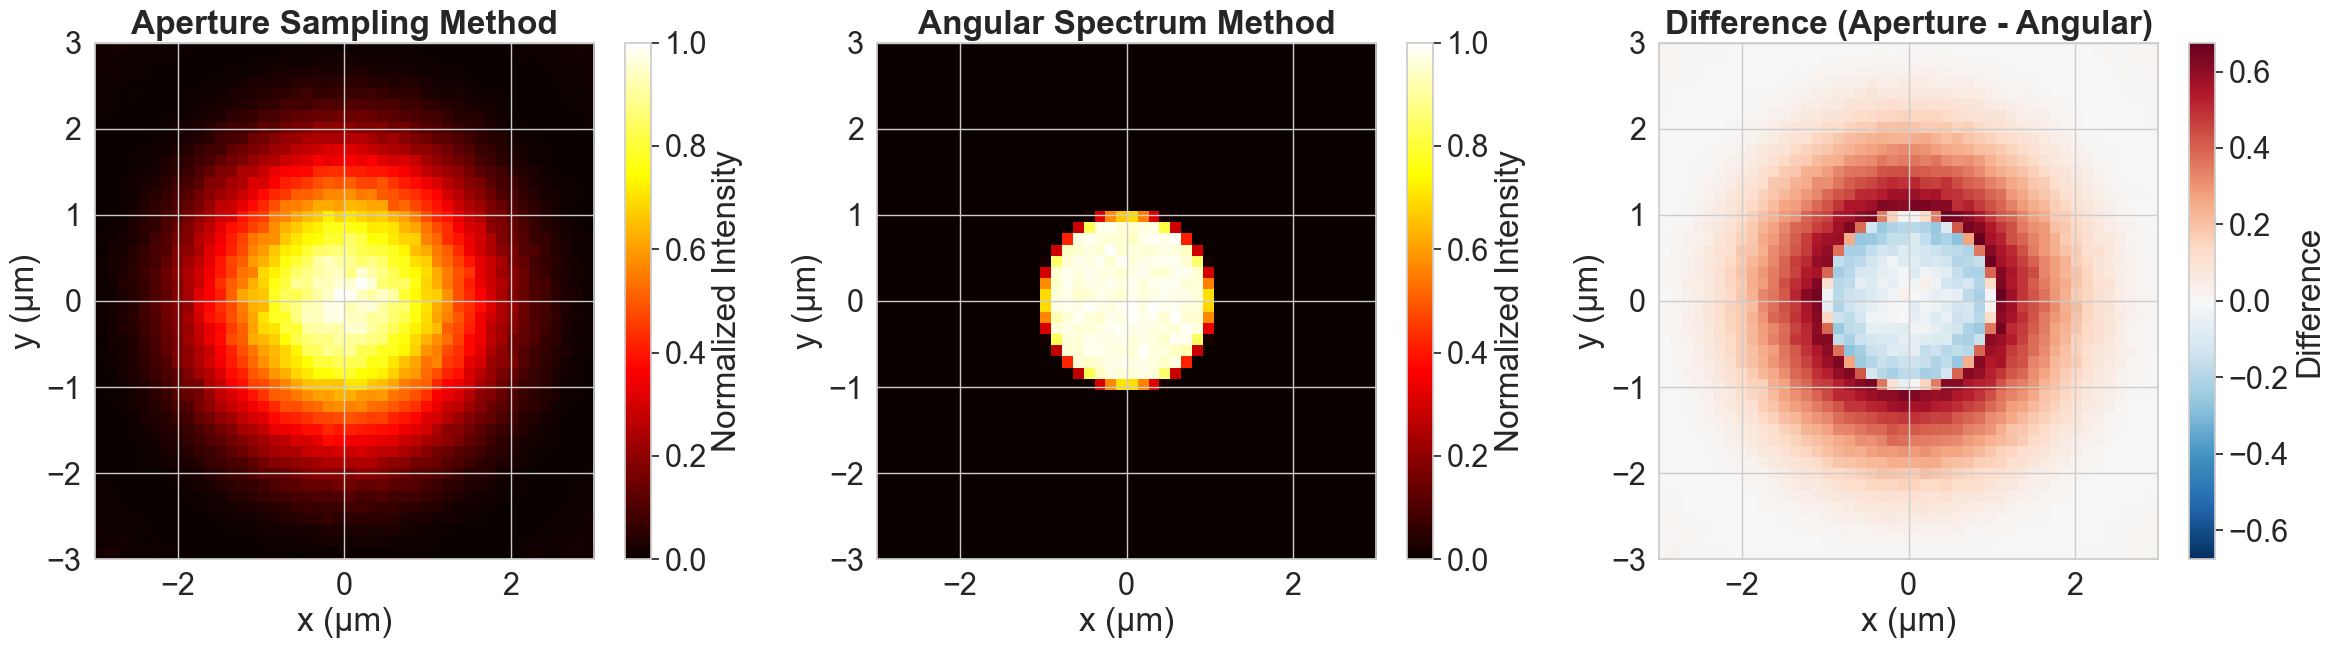

Max absolute difference: 0.675759


In [183]:
# Create 2D histogram for angular spectrum
hist_ang, _, _ = np.histogram2d(
    x_ang, y_ang, bins=bins_2d,
    range=[[-plot_range, plot_range], [-plot_range, plot_range]]
)

# Normalize
hist_ang_norm = hist_ang / np.max(hist_ang)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Aperture sampling
im1 = axes[0].imshow(hist_ap_norm.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='hot', aspect='auto', vmin=0, vmax=1)
axes[0].set_title('Aperture Sampling Method', fontweight='bold')
axes[0].set_xlabel('x (μm)')
axes[0].set_ylabel('y (μm)')
plt.colorbar(im1, ax=axes[0], label='Normalized Intensity')

# Angular spectrum
im2 = axes[1].imshow(hist_ang_norm.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='hot', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Angular Spectrum Method', fontweight='bold')
axes[1].set_xlabel('x (μm)')
axes[1].set_ylabel('y (μm)')
plt.colorbar(im2, ax=axes[1], label='Normalized Intensity')

# Difference
diff_methods = hist_ap_norm - hist_ang_norm
max_diff_methods = np.abs(diff_methods).max()
im3 = axes[2].imshow(diff_methods.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='RdBu_r', aspect='auto', vmin=-max_diff_methods, vmax=max_diff_methods)
axes[2].set_title('Difference (Aperture - Angular)', fontweight='bold')
axes[2].set_xlabel('x (μm)')
axes[2].set_ylabel('y (μm)')
plt.colorbar(im3, ax=axes[2], label='Difference')

# Set all xlim and ylim to be -3,3
for ax in axes:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.savefig(f'{output_dir}/part2_2d_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max absolute difference: {max_diff_methods:.6f}")

### Radial Profile: Aperture Sampling vs Angular Spectrum

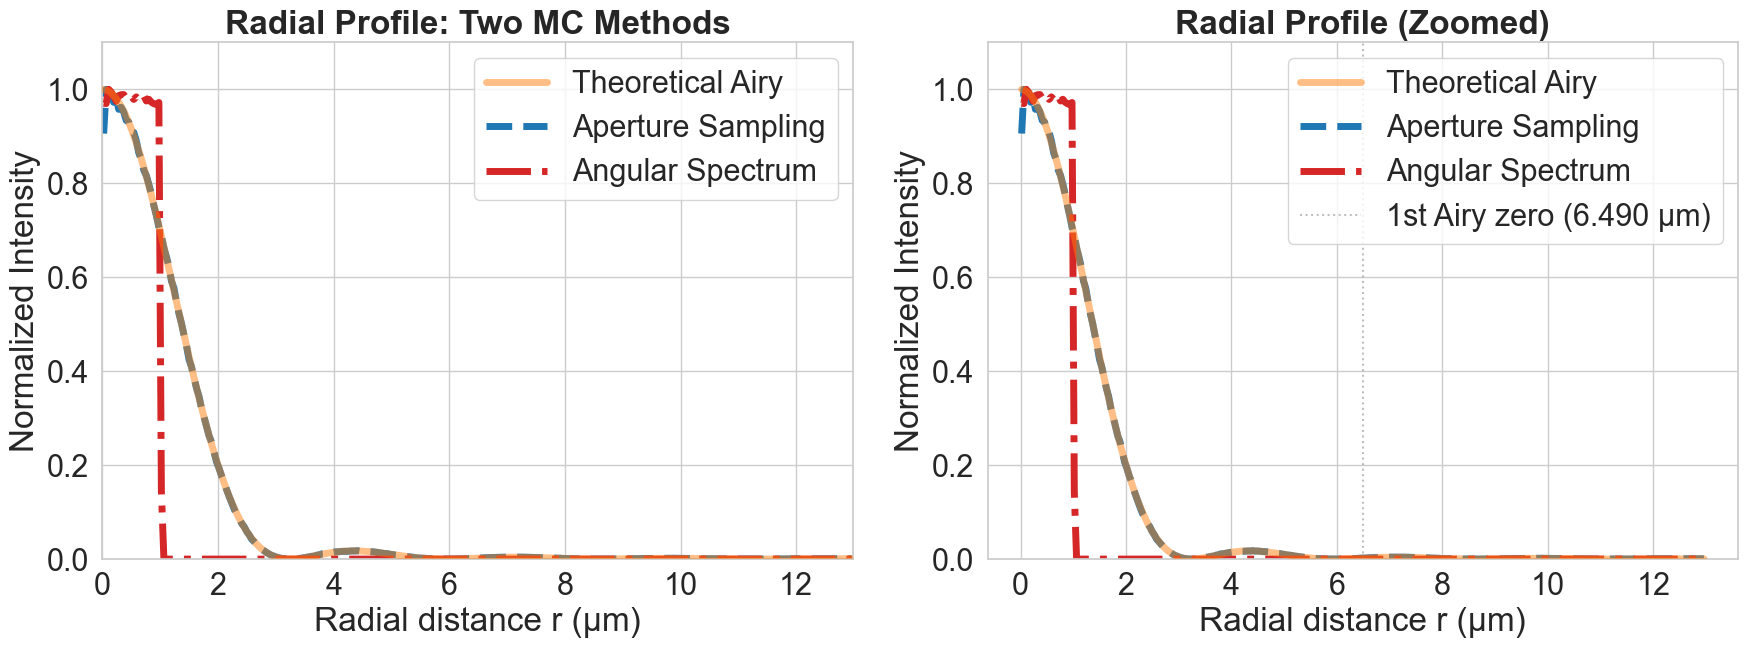

In [184]:
# Calculate radial distances for angular spectrum
r_ang = np.sqrt(x_ang**2 + y_ang**2)

# Create radial histogram for angular spectrum
hist_r_ang, _ = np.histogram(r_ang, bins=r_bins)

# Normalize by bin area
intensity_r_ang = hist_r_ang / bin_areas

# Normalize to peak
intensity_r_ang = intensity_r_ang / np.max(intensity_r_ang)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full radial profile
axes[0].plot(r_centers, airy_theory, color="tab:orange", alpha=0.5, linewidth=5, label='Theoretical Airy', zorder=3)
axes[0].plot(r_centers, intensity_r_ap, color="tab:blue", linewidth=5, label='Aperture Sampling', linestyle="--")
axes[0].plot(r_centers, intensity_r_ang, color="tab:red", linewidth=5, label='Angular Spectrum', linestyle="-.")
axes[0].set_xlabel('Radial distance r (μm)')
axes[0].set_ylabel('Normalized Intensity')
axes[0].set_title('Radial Profile: Two MC Methods', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].set_xlim([0, plot_range])
axes[0].set_ylim([0, 1.1])

# Zoomed in on first few Airy rings
axes[1].plot(r_centers[zoom_mask], airy_theory[zoom_mask], color="tab:orange", alpha=0.5, linewidth=5, 
            label='Theoretical Airy', zorder=3)
axes[1].plot(r_centers[zoom_mask], intensity_r_ap[zoom_mask], color="tab:blue", linewidth=5, 
            label='Aperture Sampling', linestyle="--")
axes[1].plot(r_centers[zoom_mask], intensity_r_ang[zoom_mask], color="tab:red", linewidth=5, 
            label='Angular Spectrum', linestyle="-.")
axes[1].axvline(airy_radius, color='gray', linestyle=':', alpha=0.5, linewidth=1.5,
               label=f'1st Airy zero ({airy_radius:.3f} μm)')
axes[1].set_xlabel('Radial distance r (μm)')
axes[1].set_ylabel('Normalized Intensity')
axes[1].set_title('Radial Profile (Zoomed)', fontweight='bold')
axes[1].legend()
axes[1].set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig(f'{output_dir}/part2_radial_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate metrics for aperture sampling vs theory using metrics module
nrmse_ap = metrics.nrmse(intensity_r_ap, airy_theory)
fid_ap = metrics.fidelity(airy_theory, intensity_r_ap)
corr_ap = metrics.correlationquality(airy_theory, intensity_r_ap)
rst_ap = metrics.rst(airy_theory, intensity_r_ap)

# Calculate metrics for angular spectrum vs theory
nrmse_ang = metrics.nrmse(intensity_r_ang, airy_theory)
fid_ang = metrics.fidelity(airy_theory, intensity_r_ang)
corr_ang = metrics.correlationquality(airy_theory, intensity_r_ang)
rst_ang = metrics.rst(airy_theory, intensity_r_ang)

# Verify Linfoot relationship: F = 2Q - S
linfoot_diff_ap = metrics.verify_linfoot_relationship(fid_ap, corr_ap, rst_ap)
linfoot_diff_ang = metrics.verify_linfoot_relationship(fid_ang, corr_ang, rst_ang)

# Print comparison table
print("\n" + "="*80)
print("QUANTITATIVE METRICS: Radial Profile vs Theoretical Airy")
print("="*80)
print(f"{'Metric':<30} {'Aperture Sampling':<25} {'Angular Spectrum':<25}")
print("-"*80)
print(f"{'NRMSE (lower better)':<30} {nrmse_ap:<25.6f} {nrmse_ang:<25.6f}")
print(f"{'Fidelity (1.0 = perfect)':<30} {fid_ap:<25.6f} {fid_ang:<25.6f}")
print(f"{'Correlation Quality':<30} {corr_ap:<25.6f} {corr_ang:<25.6f}")
print(f"{'Relative Structural (RST)':<30} {rst_ap:<25.6f} {rst_ang:<25.6f}")
print("="*80)

# Verify Linfoot relationship
print("\nLinfoot Relationship Verification (F = 2Q - S):")
print(f"  Aperture Sampling:")
print(f"    F = {fid_ap:.6f}")
print(f"    2Q - S = {2*corr_ap - rst_ap:.6f}")
print(f"    |Difference| = {linfoot_diff_ap:.9f}")
print(f"  Angular Spectrum:")
print(f"    F = {fid_ang:.6f}")
print(f"    2Q - S = {2*corr_ang - rst_ang:.6f}")
print(f"    |Difference| = {linfoot_diff_ang:.9f}")

# Determine which is better
print("\nSummary:")
if nrmse_ap < nrmse_ang:
    print(f"  - Aperture Sampling has {((nrmse_ang - nrmse_ap) / nrmse_ang * 100):.2f}% lower NRMSE")
else:
    print(f"  - Angular Spectrum has {((nrmse_ap - nrmse_ang) / nrmse_ap * 100):.2f}% lower NRMSE")

if fid_ap > fid_ang:
    print(f"  - Aperture Sampling has higher fidelity ({fid_ap:.6f} vs {fid_ang:.6f})")
else:
    print(f"  - Angular Spectrum has higher fidelity ({fid_ang:.6f} vs {fid_ap:.6f})")

if corr_ap > corr_ang:
    print(f"  - Aperture Sampling has higher correlation quality ({corr_ap:.6f} vs {corr_ang:.6f})")
else:
    print(f"  - Angular Spectrum has higher correlation quality ({corr_ang:.6f} vs {corr_ap:.6f})")

if abs(rst_ap - 1.0) < abs(rst_ang - 1.0):
    print(f"  - Aperture Sampling has RST closer to 1.0 ({rst_ap:.6f} vs {rst_ang:.6f})")
else:
    print(f"  - Angular Spectrum has RST closer to 1.0 ({rst_ang:.6f} vs {rst_ap:.6f})")


## Statistical Comparison

In [186]:
print("\nDistribution Statistics:")
print("=" * 60)
print(f"\nAperture Sampling Method:")
print(f"  Mean r: {np.mean(r_ap):.6f} μm")
print(f"  Std r:  {np.std(r_ap):.6f} μm")
print(f"  Max r:  {np.max(r_ap):.6f} μm")

print(f"\nAngular Spectrum Method:")
print(f"  Mean r: {np.mean(r_ang):.6f} μm")
print(f"  Std r:  {np.std(r_ang):.6f} μm")
print(f"  Max r:  {np.max(r_ang):.6f} μm")

print(f"\nRelative difference in mean r: {np.abs(np.mean(r_ap) - np.mean(r_ang)) / np.mean(r_ap) * 100:.2f}%")
print(f"Relative difference in std r:  {np.abs(np.std(r_ap) - np.std(r_ang)) / np.std(r_ap) * 100:.2f}%")


Distribution Statistics:

Aperture Sampling Method:
  Mean r: 2.361779 μm
  Std r:  3.506697 μm
  Max r:  32.399042 μm

Angular Spectrum Method:
  Mean r: 0.668710 μm
  Std r:  0.236979 μm
  Max r:  1.005037 μm

Relative difference in mean r: 71.69%
Relative difference in std r:  93.24%
